In [459]:
import pandas as pd
import numpy as np

**Phase 1 — Cleaning & Standardization ("The Grunt Work")**

In [460]:
subway=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/dataset/subway_turnstile.csv")
scooter=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/dataset/scooter_rides.csv")
city=pd.read_json("/content/drive/MyDrive/Colab Notebooks/dataset/city_heartbeat.json")

In [461]:
subway.shape

(1980, 4)

In [462]:
city.shape

(3, 30)

In [463]:
scooter.shape

(5000, 11)

In [464]:
print(subway.info)
print(scooter.info)
print(city.info)

<bound method DataFrame.info of      station_id            timestamp       entries exits
0       Stn_009  2026-06-21 02:00:00            73    68
1       Stn_010  2026-06-01 17:00:00           433   396
2       STN_009  2026-06-06 21:00:00           137   110
3      STN_001   2026-06-26 04:00:00            92    92
4       stn_009  2026-06-26 13:00:00            85    69
...         ...                  ...           ...   ...
1975    STN_009  2026-06-16 11:00:00           123   121
1976    stn_006  2026-06-19 15:00:00           109    88
1977    stn_001  2026-06-15 20:00:00           218   202
1978   STN_004   2026-06-22 01:00:00            86    84
1979  STN_008    2026-06-16 14:00:00  DEVICE_ERROR    84

[1980 rows x 4 columns]>
<bound method DataFrame.info of           ride_id  scooter_id     user_id           start_time  \
0     RIDE_000000  SCOOT_0048  USER_00448  2026-06-21T04:03:12   
1     RIDE_000001  SCOOT_0358  USER_00866  2026-06-08T18:23:57   
2     RIDE_000002  SCOOT_027

In [465]:
subway.describe()

,station_id,timestamp,entries,exits
count,1980,1980,1980,1980
unique,60,677,433,477
top,Stn_005,2026-06-15 14:00:00,DEVICE_ERROR,DEVICE_ERROR
freq,45,10,75,66


 Inspect subway_turnstile.csv['station_id'].unique() to see the full scope of the inconsistency.
• Use .str.strip() and .str.upper() (or .str.lower()) to collapse all variants into a single canonical
form.



In [466]:
# number of unique values
subway['station_id'].nunique()

60

In [467]:
# checking unique values
subway['station_id'].str.strip().str.upper().nunique()

10

In [468]:
subway['station_id'].str.strip().str.upper().unique()

array(['STN_009', 'STN_010', 'STN_001', 'STN_008', 'STN_006', 'STN_002',
       'STN_007', 'STN_003', 'STN_005', 'STN_004'], dtype=object)

In [469]:
subway['station_id']=subway['station_id'].str.strip().str.upper()

• Repeat the same instinct for start_lat / start_lng in scooter_rides.csv — some values are clean
floats, others padded strings like ' -74.0060 ', and others carry corrupted suffixes like '40.7128° N'.
• Strip whitespace, strip the °, N, W, and % characters where relevant, before attempting any numeric
conversion

In [470]:
# converting to float anf removing unecessary things
scooter['start_lat']=pd.to_numeric(scooter['start_lat'].str.strip().str.replace("[°wnWN]", '', regex=True))

In [471]:
# converting to float anf removing unecessary things
scooter['start_lng']=scooter['start_lng'].str.strip().str.replace("°", '', regex=False)
scooter['start_lng'] = np.where(scooter['start_lng'].str.contains('W', case=False, na=False),
    -pd.to_numeric(
        scooter['start_lng'].str.replace('[Ww]','', regex=True),
        errors='coerce'
    ),
    pd.to_numeric(
        scooter['start_lng'],
        errors='coerce'
    )
)

In [472]:
scooter

,ride_id,scooter_id,user_id,start_time,end_time,start_lat,start_lng,end_lat,end_lng,battery_level,user_rating
0,RIDE_000000,SCOOT_0048,USER_00448,2026-06-21T04:03:12,1782014832,40.740500,-73.938000,40.742477,-73.933396,55,NaN
1,RIDE_000001,SCOOT_0358,USER_00866,2026-06-08T18:23:57,06/08/2026 07:04 PM,40.711863,-74.006937,40.716601,-74.004634,1%,2
2,RIDE_000002,SCOOT_0275,USER_00256,1781172421,2026-06-11T10:19:01,40.710922,-74.003830,40.709532,-74.005227,34,4
3,RIDE_000003,SCOOT_0120,USER_00207,1782827215,06/30/2026 01:54 PM,40.705339,-74.026266,40.700164,-74.027952,99%,1
4,RIDE_000004,SCOOT_0274,USER_01494,2026-06-13T10:07:14,06/13/2026 10:39 AM,40.741100,-73.971300,40.738419,-73.975552,10%,2
...,...,...,...,...,...,...,...,...,...,...,...
4995,RIDE_004995,SCOOT_0393,USER_01146,06/24/2026 01:03 AM,2026-06-24T01:17:16,40.732100,-73.995700,40.729793,-73.995520,40,2
4996,RIDE_004996,SCOOT_0237,USER_00358,06/02/2026 08:24 AM,2026-06-02T08:31:26,40.713300,-74.009677,40.709987,-74.011719,11,4
4997,RIDE_004997,SCOOT_0354,USER_00451,06/19/2026 11:29 PM,2026-06-20T00:13:46,40.720946,-74.007651,40.724645,-74.009057,29,NaN
4998,RIDE_004998,SCOOT_0109,USER_01076,2026-06-05T11:55:02,2026-06-05T12:06:02,40.766200,-73.967700,40.769035,-73.966487,low,4


In [473]:
scooter.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ride_id        5000 non-null   object 
 1   scooter_id     5000 non-null   object 
 2   user_id        5000 non-null   object 
 3   start_time     5000 non-null   object 
 4   end_time       5000 non-null   object 
 5   start_lat      5000 non-null   float64
 6   start_lng      5000 non-null   float64
 7   end_lat        5000 non-null   float64
 8   end_lng        5000 non-null   float64
 9   battery_level  4873 non-null   object 
 10  user_rating    4507 non-null   object 
dtypes: float64(4), object(7)
memory usage: 429.8+ KB


1.2 Type Casting


• battery_level mixes integers, '85%', whitespace-padded numbers, and outright non-numeric strings ('LOW',
'N/A'). Strip any non-digit characters, then cast to a numeric type using pd.to_numeric(...,
errors='coerce') so unsalvageable values become NaN instead of crashing your pipeline.


In [474]:
scooter['battery_level']=scooter['battery_level'].str.strip().str.lower().str.replace("%",'',regex=False)
scooter['battery_level']=pd.to_numeric(scooter['battery_level'],errors='coerce')

In [475]:
scooter['battery_level'].dtype

dtype('float64')

In [476]:
print(subway['entries'].dtype)
subway['entries']=pd.to_numeric(subway['entries'].str.strip(),errors='coerce')
print(subway['entries'].dtype)


object
float64


• entries and exits in the turnstile data contain the string 'DEVICE_ERROR' mixed in with legitimate integer
counts. Apply the same errors='coerce' pattern.


In [477]:
print(subway['exits'].dtype)
subway['exits']=pd.to_numeric(subway['exits'].str.strip(),errors='coerce')
print(subway['exits'].dtype)


object
float64


• user_rating is 10% blank and 5% written as text ('five star', '1.0'). Decide on — and document — a
strategy: do you map text values to numbers, or treat them as missing?


 I observed that user_rating contains 10% blank fields and 5% text-based ratings. I choose to opt for the mapping technique('five star' --> 5.0) to preserve as much user feedback data as possible. All truly blank or unresolvable text entries were coerced into nan using pd.to_numeric(). If i choose second option it will be easy and less code but 5% data will be lost as 10% is already missing.

In [478]:
scooter['user_rating']=scooter['user_rating'].str.strip().str.lower().str.split(' ').str[0].replace(
    "five","5.0"
    ).replace("one","1.0").replace("two","2.0").replace("three","3.0").replace("four","4.0")

In [479]:
scooter['user_rating']=pd.to_numeric(scooter['user_rating'],errors='coerce')

• start_time / end_time arrive in three different formats: ISO 8601 strings, US-style MM/DD/YYYY
HH:MM AM/PM strings, and raw Unix epoch integers. A single pd.to_datetime() call will not handle
all three at once — you'll need to detect the format per-row (hint: check if the value is numeric first) before
parsing, or parse in batches by format.


In [480]:
epoch = scooter['start_time'].str.isnumeric()
scooter.loc[epoch, 'start_time'] = pd.to_datetime(
    pd.to_numeric(
        scooter.loc[epoch, 'start_time']
    ),
    unit='s'
)

In [481]:
# , US-style MM/DD/YYYY HH:MM AM/PM strings
mask=scooter['start_time'].str.contains('AM|PM',na=False)
scooter.loc[mask,"start_time"]=pd.to_datetime(scooter.loc[mask,"start_time"],format='%m/%d/%Y %I:%M %p')

In [482]:
#  ISO 8601 strings
scooter["start_time"]=pd.to_datetime(scooter["start_time"])


In [483]:
# for epoch
epoch = scooter['end_time'].str.isnumeric()
scooter.loc[epoch, 'end_time'] = pd.to_datetime(
    pd.to_numeric(
        scooter.loc[epoch, 'end_time']
    ),
    unit='s'
)

In [484]:
# , US-style MM/DD/YYYY HH:MM AM/PM strings
mask=scooter['end_time'].str.contains('AM|PM',na=False)
scooter.loc[mask,"end_time"]=pd.to_datetime(scooter.loc[mask,"end_time"],format='%m/%d/%Y %I:%M %p')

In [485]:
#  ISO 8601 strings
scooter["end_time"]=pd.to_datetime(scooter["end_time"])


In [486]:
scooter.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   ride_id        5000 non-null   object        
 1   scooter_id     5000 non-null   object        
 2   user_id        5000 non-null   object        
 3   start_time     5000 non-null   datetime64[ns]
 4   end_time       5000 non-null   datetime64[ns]
 5   start_lat      5000 non-null   float64       
 6   start_lng      5000 non-null   float64       
 7   end_lat        5000 non-null   float64       
 8   end_lng        5000 non-null   float64       
 9   battery_level  4494 non-null   float64       
 10  user_rating    4507 non-null   float64       
dtypes: datetime64[ns](2), float64(6), object(3)
memory usage: 429.8+ KB


In [487]:
subway['timestamp']=pd.to_datetime(subway.loc[:,'timestamp'])

In [488]:
subway.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1980 entries, 0 to 1979
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   station_id  1980 non-null   object        
 1   timestamp   1980 non-null   datetime64[ns]
 2   entries     1905 non-null   float64       
 3   exits       1914 non-null   float64       
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 62.0+ KB


.3 Handling Anomalies
Turnstiles cannot log a negative number of people. Yet 5% of your entries/exits values are negative.
Line of Action:
• Quantify the problem first: what percentage of rows have negative values? Is it random noise, or
concentrated somewhere?

In [489]:
neg=subway[(subway['entries'] < 0) |(subway['exits'] < 0)].copy()

print("Negative rows:", len(neg))
print("Percentage:", len(neg)/len(subway)*100)

Negative rows: 165
Percentage: 8.333333333333332


In [490]:
neg['station_id'].value_counts()

,count
station_id,
STN_005,21
STN_003,20
STN_009,19
STN_008,19
STN_010,17
STN_001,15
STN_007,14
STN_006,14
STN_002,13


In [491]:
neg['day'] = neg['timestamp'].dt.day
neg['day'].value_counts()

,count
day,
15,17
2,9
25,9
28,8
30,8
20,7
22,7
7,7
11,7


In [492]:
neg['hour'] = neg.loc[:,'timestamp'].dt.hour
neg.loc[:,'hour'].value_counts()

,count
hour,
5,11
6,10
7,10
18,9
12,9
3,8
8,8
17,8
9,8


In [493]:

subway[
    ((subway['timestamp'].dt.day) == 15) &
    ((subway['timestamp'].dt.hour).between(14,20))&
    (subway['station_id'] =='STN_003')
]


,station_id,timestamp,entries,exits
261,STN_003,2026-06-15 15:00:00,7.0,7.0
447,STN_003,2026-06-15 19:00:00,21.0,22.0
474,STN_003,2026-06-15 16:00:00,11.0,11.0
595,STN_003,2026-06-15 17:00:00,19.0,18.0
757,STN_003,2026-06-15 18:00:00,25.0,25.0
1207,STN_003,2026-06-15 20:00:00,231.0,207.0
1518,STN_003,2026-06-15 14:00:00,4.0,4.0


 Decide on a defensible handling strategy (e.g., take the absolute value if you believe it's a sign-flip bug, or
treat as missing if you believe it's a corrupted read) — and justify your choice in a markdown cell.
• Do not silently drop these rows without checking whether they cluster around a particular station, day, or
hour — that clustering might itself be a clue.

according to my analysis if the values are neagtive between 14-20 on day 15 convert them to nan but in this case they are spread in multiple stations and the neagtive values are 8% so it is better to treat them as sign-flip errorsand use absolute values.

In [494]:
subway['entries'] = subway['entries'].abs()
subway['exits'] = subway['exits'].abs()


In [495]:
print((subway['entries']<0).sum())
print((subway['exits']<0).sum())

0
0


In [496]:
subway['entries']

,entries
0,73.0
1,433.0
2,137.0
3,92.0
4,85.0
...,...
1975,123.0
1976,109.0
1977,218.0
1978,86.0


**Phase 2 — Aggregation & Group By ("Finding the Signal")**

 Use .groupby() on your cleaned subway_turnstile data to calculate:
◦ Daily total entries/exits per station
◦ Average hourly turnstile flow per station

In [497]:
subway['date'] = subway['timestamp'].dt.date
daily_totals = subway.groupby(['station_id','date']).agg(
    total_entries=('entries','sum'),
    total_exits=('exits','sum')
)
daily_totals

total_entries  total_exits
station_id date                                  
STN_001    2026-06-01          829.0        647.0
           2026-06-02         1549.0       1412.0
           2026-06-03         1358.0       1200.0
           2026-06-04         1675.0       1252.0
           2026-06-05         1535.0       1294.0
...                              ...          ...
STN_010    2026-06-26          578.0        534.0
           2026-06-27         1335.0       1404.0
           2026-06-28          771.0        833.0
           2026-06-29         1669.0       1669.0
           2026-06-30         1017.0        944.0

[300 rows x 2 columns]

**Average hourly tursile flow**

In [498]:
subway['hour'] = subway['timestamp'].dt.hour
subway['flow'] = subway['entries'] + subway['exits']

In [499]:
hourly_pattern = subway.groupby(
    ['station_id','hour']
).agg(
    avg_flow=('flow','mean')
)
hourly_pattern

avg_flow
station_id hour            
STN_001    0     152.800000
           1     150.416667
           2     146.714286
           3     162.200000
           4     167.200000
...                     ...
STN_010    19    837.600000
           20    473.777778
           21    240.000000
           22    168.000000
           23    152.800000

[240 rows x 1 columns]

Use .groupby() on your cleaned scooter_rides data to calculate daily ride counts and average battery levels
city-wide.


In [500]:
scooter['date']=scooter['start_time'].dt.date
scooter.groupby('date').agg(
    ride_count=('ride_id','count'),
    avg_battery=('battery_level','mean'))

,ride_count,avg_battery
date,,
2026-06-01,190,54.179641
2026-06-02,165,51.446667
2026-06-03,157,51.979167
2026-06-04,177,53.468750
2026-06-05,165,48.600000
2026-06-06,133,44.512195
2026-06-07,144,48.496124
2026-06-08,165,49.832215
2026-06-09,150,53.643939


The Bounding Box: STN_003 sits at approximately (40.7128, -74.0060). Define a lat/lng bounding box
(e.g., ± 0.006 degrees in each direction) around this point, and filter scooter_rides down to only the rides
whose start_lat/start_lng fall inside it. This isolates scooter activity in STN_003's immediate neighborhood
— the population you'll need for Phase 4.


In [506]:
stn_lat=40.7128
stn_lat_upper=stn_lat+0.006
stn_lat_lower=stn_lat-0.006
stn_lng=-74.0060
stn_lng_upper=stn_lng+0.006
stn_lng_lower=stn_lng-0.006
print(stn_lat_lower, stn_lat_upper)
print(stn_lng_lower, stn_lng_upper)
stn003 = scooter[
    (scooter['start_lat'].between(stn_lat_lower, stn_lat_upper)) &
    (scooter['start_lng'].between(stn_lng_lower, stn_lng_upper))
]
box_rides = len(stn003)
city_total = len(scooter)
box_rides/city_total*100

40.7068 40.7188
-74.012 -74.0


30.580000000000002

stn-003 bounding box representing 30.58% of all rides. This is  high for a single neighborhood but remains plausible because the ±0.006 degree boundary covers a sizable area around STN_003. The result suggests that the station is  highly active.

**Phase 3 — Advanced Reshaping ("The Pivot Table")**


• Filter your cleaned turnstile data down to Day 15 only.


In [525]:
day15=subway[(subway['timestamp'].dt.day )==15]

• Build a .pivot_table() with hour as the index, station_id as the columns, and entries (or exits) as the
values, aggregated with mean or sum.

In [537]:
pivot=day15.pivot_table(index='hour',columns='station_id',values='entries',aggfunc='sum')

Scan the resulting table (or better, apply a conditional style / heatmap) across all 10 stations for Day 15. One
column should visibly collapse between certain hours while its neighbors stay steady.

<Axes: xlabel='station_id', ylabel='hour'>

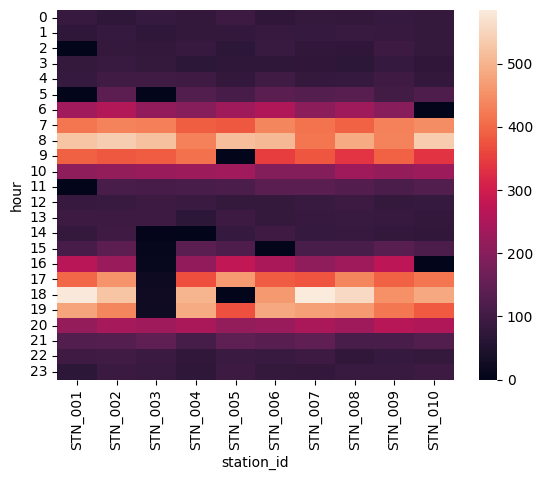

In [531]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(pivot)

On Day 15 stn-003  shows a sudden drop in entries between 14:00-20:00 while neighboring stations maintained relatively stable traffic levels. This pattern suggests an anomaly in stn_003 rather than a city-wide decrease in activity.

**Phase 4 — Multimodal Visualization ("The Reveal")**


In [538]:
pivot

station_id,STN_001,STN_002,STN_003,STN_004,STN_005,STN_006,STN_007,STN_008,STN_009,STN_010
hour,,,,,,,,,,
0,86.0,73.0,83.0,78.0,92.0,75.0,80.0,78.0,83.0,82.0
1,72.0,84.0,71.0,78.0,78.0,85.0,83.0,88.0,85.0,81.0
2,0.0,80.0,78.0,85.0,69.0,89.0,76.0,75.0,92.0,80.0
3,80.0,87.0,82.0,69.0,71.0,71.0,75.0,69.0,83.0,74.0
4,84.0,99.0,100.0,98.0,78.0,99.0,82.0,83.0,98.0,78.0
5,0.0,140.0,0.0,125.0,110.0,139.0,130.0,137.0,104.0,119.0
6,235.0,257.0,214.0,198.0,233.0,255.0,204.0,232.0,201.0,0.0
7,418.0,434.0,428.0,387.0,380.0,438.0,412.0,391.0,430.0,447.0
8,524.0,538.0,519.0,431.0,516.0,508.0,416.0,488.0,432.0,536.0


In [637]:
st=stn003[(stn003['start_time'].dt.day)==15].copy()
st['hour']=st['start_time'].dt.hour
scooter_ride=st.groupby('hour').agg(
    ride_count=('ride_id','count'),
).reindex(range(24), fill_value=0)
scooter_ride

,ride_count
hour,
0,1
1,3
2,4
3,1
4,5
5,3
6,1
7,1
8,1


In [631]:
city_copy=city.transpose().copy()
# city_copy=city_copy.set_index('day_number')
# city_copy.iloc(2)
day15=city_copy[city_copy['day_number']==15]
rain = day15['weather'].iloc[0]['precipitation_mm']
# city_copy.columns=pd.to_datetime(city_copy.columns)


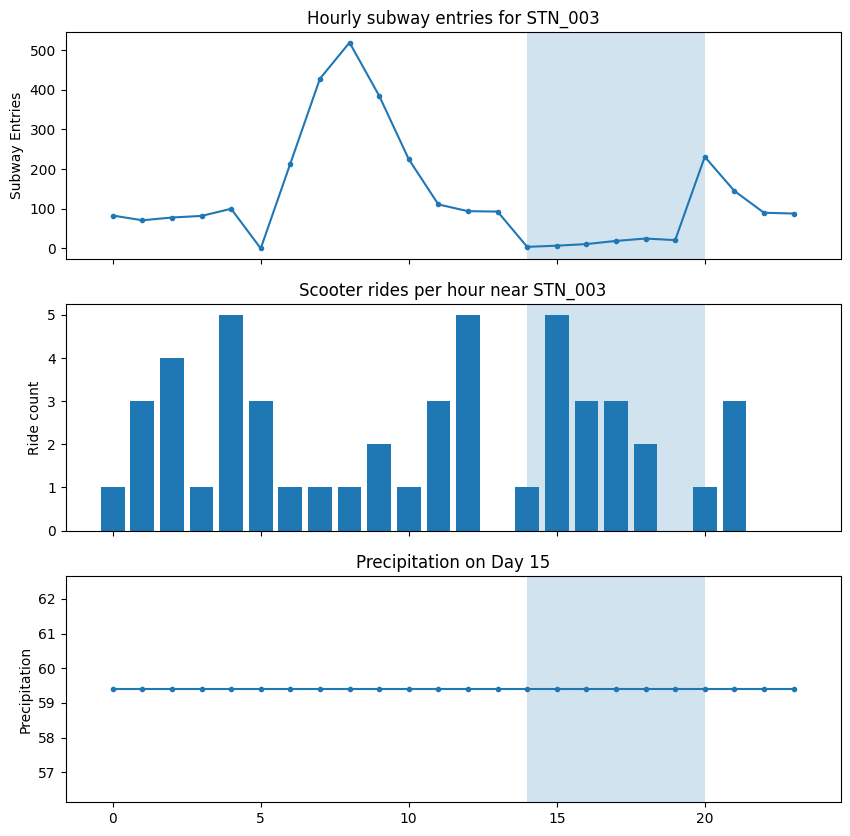

In [644]:
fig , ax = plt.subplots(3, 1, sharex=True, figsize=(10,10))
# ◦ Panel 1 — Hourly subway entries for STN_003 (line or bar) — from your Phase 3 pivot table.
ax[0].plot(pivot.index,pivot['STN_003'],marker='.')
ax[0].axvspan(14, 20, alpha=0.2)
ax[0].set_title('Hourly subway entries for STN_003')
ax[0].set_ylabel('Subway Entries')
# ◦ Panel 2 — Scooter rides per hour near STN_003 (bar) — count rides starting each hour on
#  Day 15,from your Phase 2 bounding-box subse
ax[1].bar(scooter_ride.index,scooter_ride['ride_count'])
ax[1].set_title('Scooter rides per hour near STN_003')
ax[1].set_ylabel('Ride count')

ax[1].axvspan(14, 20, alpha=0.2)
# ◦ Panel 3 — Precipitation on Day 15 (line or bar) — from city_heartbeat.json (remember: the date
# # keys are inconsistently formatted, so standardize them before looking up "Day 15").
ax[2].plot(range(24),
    [rain]*24,marker='.'
)
ax[2].set_title('Precipitation on Day 15')
ax[2].set_ylabel('Precipitation')
ax[2].axvspan(14, 20, alpha=0.2)
fig.savefig("dashboard.png", bbox_inches='tight')


**Final Verdict**
